<a href="https://colab.research.google.com/github/Devadeeps/fpga-ml-thermal-management/blob/main/evaluation_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regression MSE: 0.39864499999994063
Q-table after training:
[[9.99916195 9.58575741 9.55559265]
 [0.         0.         0.        ]
 [0.         0.         0.        ]]
PWM Frequency Adjustment MSE: 116.46500000000005
Accuracy: 0.5
Classification Report:
               precision    recall  f1-score   support

       False       0.50      1.00      0.67         1
        True       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

Overheat Risk Prediction for Simulation Data: [False]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


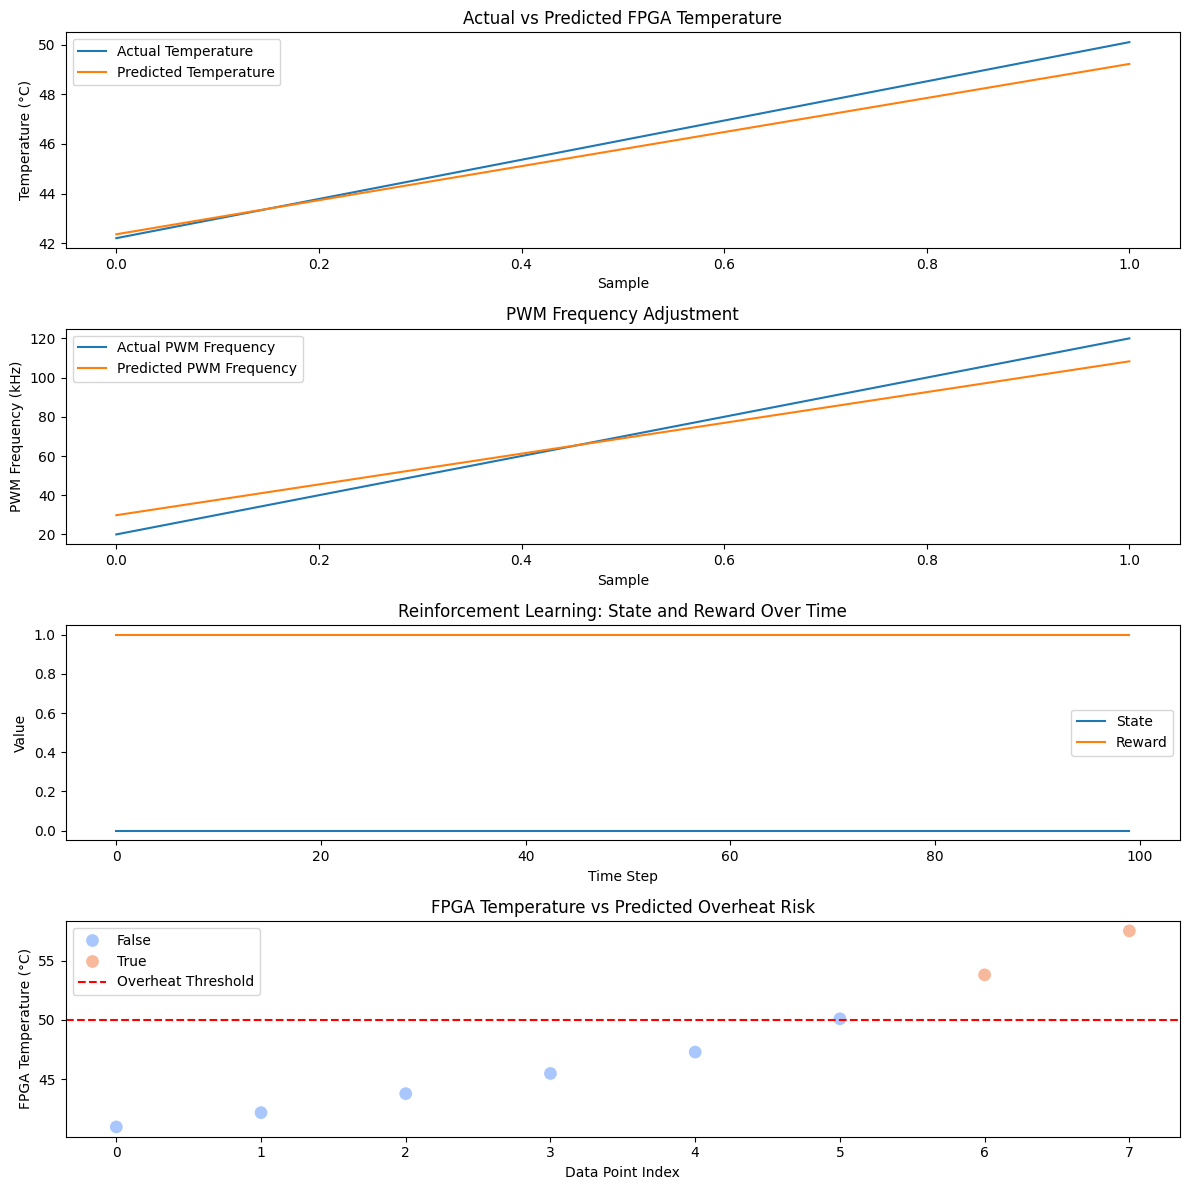

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

# Load dataset
data = {
    "V_in (V)": [1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2],
    "I_in (A)": [0.4, 0.5, 0.6, 0.8, 1.0, 1.2, 1.5, 1.8],
    "FPGA Power (W)": [0.48, 0.60, 0.72, 0.96, 1.20, 1.44, 1.80, 2.16],
    "PWM Duty (%)": [30, 40, 50, 65, 75, 85, 90, 95],
    "Freq (kHz)": [10, 20, 50, 75, 100, 120, 150, 180],
    "Ambient Temp (°C)": [25, 26, 27, 28, 30, 32, 34, 36],
    "Cooling Fan (RPM)": [1200, 1300, 1350, 1400, 1500, 1600, 1700, 1800],
    "Prev FPGA Temp (°C)": [40, 41, 42, 44, 45, 47, 50, 53],
    "Heat sink Temp (°C)": [38, 39, 40, 42, 43, 45, 48, 51],
    "FPGA Temp (°C)": [41, 42.2, 43.8, 45.5, 47.3, 50.1, 53.8, 57.5]
}

df = pd.DataFrame(data)

# Regression: Predict Future Temperature
# Features and target
X = df.drop("FPGA Temp (°C)", axis=1)
y = df["FPGA Temp (°C)"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train regression model
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

# Predict future temperature
y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Regression MSE: {mse}")

# Reinforcement Learning: Optimize Power Output Dynamically
class FPGAEnvironment:
    def __init__(self):
        self.state = 0  # Initial state (e.g., normal temperature)
        self.temp_threshold = 50  # Overheat threshold
        self.action_space = [0, 1, 2]  # Actions: 0 = decrease power, 1 = maintain, 2 = increase power
        self.state_space = 3  # States: 0 = normal, 1 = warning, 2 = critical
        self.temperature = 40  # Initial temperature

    def step(self, action):
        # Simulate temperature change based on action
        if action == 0:
            self.temperature = max(35, self.temperature - 2)  # Decrease power
        elif action == 1:
            self.temperature = min(60, self.temperature + 0.5)  # Maintain power
        elif action == 2:
            self.temperature = min(60, self.temperature + 2)  # Increase power

        # Update state based on temperature
        if self.temperature < 45:
            self.state = 0  # Normal state
        elif 45 <= self.temperature < 50:
            self.state = 1  # Warning state
        else:
            self.state = 2  # Critical state

        # Reward function
        if self.state == 0:
            reward = 1  # Normal state
        elif self.state == 1:
            reward = -1  # Warning state
        else:
            reward = -10  # Critical state

        return self.state, reward

class QLearning:
    def __init__(self, env, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.env = env
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.q_table = np.zeros((env.state_space, len(env.action_space)))

    def choose_action(self, state):
        if np.random.uniform(0, 1) < self.epsilon:
            return np.random.choice(self.env.action_space)  # Explore
        else:
            return np.argmax(self.q_table[state])  # Exploit

    def update_q_table(self, state, action, reward, next_state):
        self.q_table[state, action] += self.alpha * (
            reward + self.gamma * np.max(self.q_table[next_state]) - self.q_table[state, action]
        )

# Train RL agent
env = FPGAEnvironment()
q_agent = QLearning(env)

for episode in range(1000):
    state = env.state
    action = q_agent.choose_action(state)
    next_state, reward = env.step(action)
    q_agent.update_q_table(state, action, reward, next_state)

print("Q-table after training:")
print(q_agent.q_table)

# Regression for PWM Frequency Adjustment
# Features and target for PWM frequency adjustment
X_pwm = df.drop(["FPGA Temp (°C)", "PWM Duty (%)", "Freq (kHz)"], axis=1)  # Features
y_pwm = df["Freq (kHz)"]  # Target (PWM frequency)

# Split dataset
X_train_pwm, X_test_pwm, y_train_pwm, y_test_pwm = train_test_split(X_pwm, y_pwm, test_size=0.2, random_state=42)

# Train regression model for PWM frequency adjustment
pwm_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
pwm_regressor.fit(X_train_pwm, y_train_pwm)

# Predict PWM frequency
y_pred_pwm = pwm_regressor.predict(X_test_pwm)
mse_pwm = mean_squared_error(y_test_pwm, y_pred_pwm)
print(f"PWM Frequency Adjustment MSE: {mse_pwm}")

# Classification: Overheat Risk Prediction
# Define a threshold for overheating risk
overheat_threshold = 50  # Example threshold in °C
df['Overheat Risk'] = df['FPGA Temp (°C)'] > overheat_threshold

# Features and target variable
X_class = df.drop(['FPGA Temp (°C)', 'Overheat Risk'], axis=1)
y_class = df['Overheat Risk']

# Split the data into training and testing sets
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train_class, y_train_class)

# Predict on the test set
y_pred_class = classifier.predict(X_test_class)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
print("Classification Report:\n", classification_report(y_test_class, y_pred_class))

# Simulation result
simulation_data = {
    "V_in (V)": [1.2],
    "I_in (A)": [1.0],
    "FPGA Power (W)": [1.20],
    "PWM Duty (%)": [75],
    "Freq (kHz)": [100],
    "Ambient Temp (°C)": [30],
    "Cooling Fan (RPM)": [1500],
    "Prev FPGA Temp (°C)": [45],
    "Heat sink Temp (°C)": [43]
}

simulation_df = pd.DataFrame(simulation_data)
prediction = classifier.predict(simulation_df)
print("Overheat Risk Prediction for Simulation Data:", prediction)

# Predict on the entire dataset for visualization
df['Predicted Overheat Risk'] = classifier.predict(X_class)

# Simulation Output
# Simulate regression predictions for FPGA temperature
y_pred_temp = regressor.predict(X_test)

# Simulate PWM frequency adjustment predictions
y_pred_pwm = pwm_regressor.predict(X_test_pwm)

# Simulate RL actions
states = []
rewards = []
env = FPGAEnvironment()
q_agent = QLearning(env)

for _ in range(100):
    state = env.state
    action = q_agent.choose_action(state)
    next_state, reward = env.step(action)
    q_agent.update_q_table(state, action, reward, next_state)
    states.append(state)
    rewards.append(reward)

# Plot results
plt.figure(figsize=(12, 12))

# Regression: Actual vs Predicted Temperature
plt.subplot(4, 1, 1)
plt.plot(y_test.values, label="Actual Temperature")
plt.plot(y_pred_temp, label="Predicted Temperature")
plt.xlabel("Sample")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.title("Actual vs Predicted FPGA Temperature")

# PWM Frequency Adjustment
plt.subplot(4, 1, 2)
plt.plot(y_test_pwm.values, label="Actual PWM Frequency")
plt.plot(y_pred_pwm, label="Predicted PWM Frequency")
plt.xlabel("Sample")
plt.ylabel("PWM Frequency (kHz)")
plt.legend()
plt.title("PWM Frequency Adjustment")

# RL: State and Reward Over Time
plt.subplot(4, 1, 3)
plt.plot(states, label="State")
plt.plot(rewards, label="Reward")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.title("Reinforcement Learning: State and Reward Over Time")

# Classification: FPGA Temperature vs Predicted Overheat Risk
plt.subplot(4, 1, 4)
sns.scatterplot(x=df.index, y='FPGA Temp (°C)', data=df, hue='Predicted Overheat Risk', palette='coolwarm', s=100)
plt.axhline(y=overheat_threshold, color='r', linestyle='--', label='Overheat Threshold')
plt.title('FPGA Temperature vs Predicted Overheat Risk')
plt.xlabel('Data Point Index')
plt.ylabel('FPGA Temperature (°C)')
plt.legend()

plt.tight_layout()
plt.show()